# Análisis de Calidad de Datos Simulados
Los datos que se van a analizar fueron generados por la IA, Claude

### 0. Importaciones

In [50]:
#Instalar librerías necesarias 
# pip install ipykernel pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import entropy
import warnings
warnings.filterwarnings("ignore")

### 1. Carga de Dataset

In [3]:
# Ajustar la ruta del archivo
from pathlib import Path

ROOT = Path().resolve().parents[0]
FILE_PATH = ROOT / "data" /"company_dataset.csv"

df = pd.read_csv(FILE_PATH, parse_dates=["start_date"])

print("Dataset cargado")
print(f"Filas    : {len(df):,}")
print(f"Columnas : {len(df.columns)}")
print("Vista previa:")
df.head(10)

Dataset cargado
Filas    : 10,000
Columnas : 7
Vista previa:


,assigned_tasks,completed_tasks,absences,employee_calls,work_mode,location,start_date
0,21,20,1,2,Remota,Bogotá,2023-11-05
1,16,6,1,3,Híbrida,Bogotá,2018-06-23
2,13,12,2,2,Híbrida,Bogotá,2020-01-25
3,21,7,3,7,Remota,Medellín,2023-06-12
4,11,10,1,2,Remota,Medellín,2021-04-19
5,17,8,3,3,Remota,Cartagena,2023-04-01
6,15,8,3,0,Remota,Bogotá,2024-05-09
7,9,6,0,5,Híbrida,Medellín,2017-09-01
8,22,15,2,1,Remota,Cali,2023-01-24
9,13,9,0,2,Híbrida,Cali,2019-03-18


In [5]:
# Tipos de datos detectados
print("Tipos de datos:")
print(df.dtypes)
print("Info general:")
df.info()

Tipos de datos:
assigned_tasks              int64
completed_tasks             int64
absences                    int64
employee_calls              int64
work_mode                     str
location                      str
start_date         datetime64[us]
dtype: object
Info general:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   assigned_tasks   10000 non-null  int64         
 1   completed_tasks  10000 non-null  int64         
 2   absences         10000 non-null  int64         
 3   employee_calls   10000 non-null  int64         
 4   work_mode        10000 non-null  str           
 5   location         10000 non-null  str           
 6   start_date       10000 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(4), str(2)
memory usage: 547.0 KB


### 2. Valores Nulos

In [20]:
# Si existen valores nulos, mostrar el conteo y porcentaje por columna
if df.isnull().any().any(): 
    nulls = df.isnull().sum().reset_index()
    print("\nValores nulos:")
    print(nulls[nulls > 0] if nulls.sum() > 0 else "✅ Sin nulos")
    nulls.columns = ["Columna", "Nulos"]
    nulls["Porcentaje (%)"] = (nulls["Nulos"] / len(df) * 100).round(2)
    nulls
else: 
    print("No se encontraron valores nulos en el dataset.")

No se encontraron valores nulos en el dataset.


EL dataset creado no contiene nulls, sin embargo, en caso de que los tenga, debería realizarse una limpieza del dataset antes de hacer un análisis, ya que podría afectar el entrenamiento de datos de la IA.

### 3. Consistencia Lógica

In [ ]:
# Validar que no existan tareas completadas mayores a las asignadas
v1 = (df["completed_tasks"] > df["assigned_tasks"]).sum()
print(f"Cantidad de empleados con más tareas completadas que asignadas: {v1}")

# Validar que no existan valores negativos en las columnas numéricas
print ("\nValores negativos en columnas numéricas:")
for col in ["assigned_tasks", "completed_tasks", "absences", "employee_calls"]:
    print(f"{col}: {(df[col] < 0).sum()} negativos")

# Validar que no existan empleados con más de 20 ausencias (días hábiles en un mes)
v3 = (df["absences"] > 20).sum()
print(f"\nCantidad de empleados con más de 20 ausencias: {v3}")

# Validar que los valores en la columna "work_mode" sean válidos
valid_modes = ["Remota", "Híbrida"]
invalid_wm = (~df["work_mode"].isin(valid_modes)).sum()
if invalid_wm > 0:
    print(f"Modos de trabajo inválidos: {invalid_wm}")
    print("Valores únicos encontrados:", df["work_mode"].unique())
else:
    print("Todos los modos de trabajo son válidos.")

# Validar que no existan fechas de inicio futuras
print("Fechas futuras:", (df["start_date"] > pd.Timestamp.now()).sum())

Cantidad de empleados con más tareas completadas que asignadas: 0

Valores negativos en columnas numéricas:
assigned_tasks: 0 negativos
completed_tasks: 0 negativos
absences: 0 negativos
employee_calls: 0 negativos

Cantidad de empleados con más de 20 ausencias: 0
Modos de trabajo inválidos: 10000
Valores únicos encontrados: <StringArray>
['Remota', 'Híbrida']
Length: 2, dtype: str
Fechas futuras: 0


### 4. Distribución Estadística

In [ ]:
num_cols = ["assigned_tasks", "completed_tasks", "absences", "employee_calls"]

# Estadísticas descriptivas completas
stats_df = df[num_cols].describe().T.round(2)
stats_df["sesgo"] = df[num_cols].skew().round(3)
stats_df["CV (%)"] = (df[num_cols].std() / df[num_cols].mean() * 100).round(1) # coeficiente de variación
print(stats_df.to_string())

                   count   mean   std  min   25%   50%   75%   max  sesgo  CV (%)
assigned_tasks   10000.0  17.23  6.99  3.0  12.0  16.0  21.0  53.0  0.658    40.6
completed_tasks  10000.0  11.64  4.76  1.0   8.0  11.0  15.0  37.0  0.647    40.9
absences         10000.0   2.98  2.29  0.0   1.0   3.0   4.0  17.0  1.036    76.9
employee_calls   10000.0   2.13  1.57  0.0   1.0   2.0   3.0  12.0  0.988    73.5


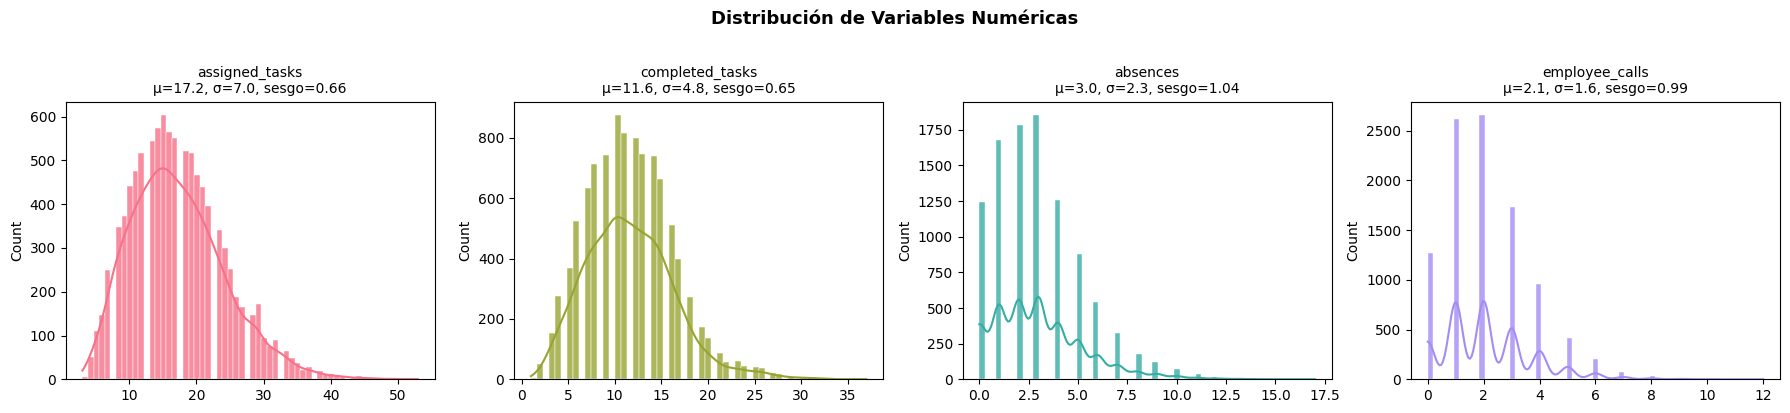

In [ ]:
# Histogramas
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col, color in zip(axes, num_cols, sns.color_palette("husl", n_colors=4)):
    s = df[col].dropna() # dropna en caso de que hayan (en este caso, no hay, pero sirve si se cambian los datos), para evitar errores
    sns.histplot(s, kde=True, ax=ax, color=color, edgecolor="white", alpha=0.8)
    ax.set_title(f"{col}\nμ={s.mean():.1f}, σ={s.std():.1f}, sesgo={s.skew():.2f}", fontsize=10)
    ax.set_xlabel("")

plt.suptitle("Distribución de Variables Numéricas", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


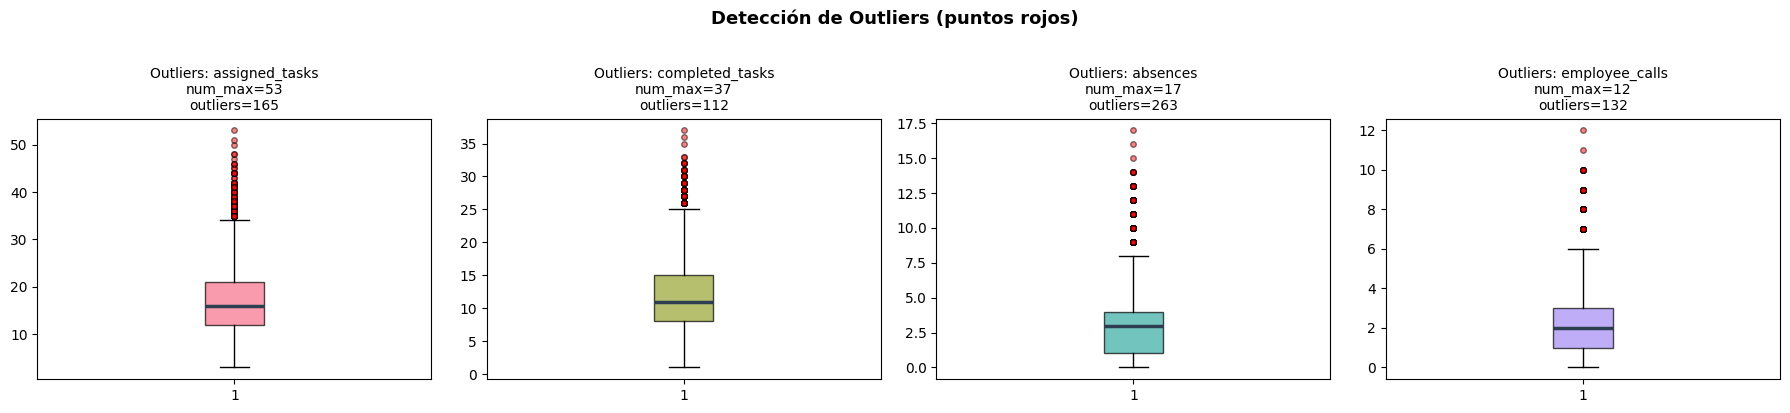

In [36]:
# Boxplots para detectar outliers
def detect_outliers(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((df[col] < lower) | (df[col] > upper)).sum()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col, color in zip(axes, num_cols, sns.color_palette("husl", n_colors=4)):
    bp = ax.boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color="#2c3e50", linewidth=2.5),
                    flierprops=dict(marker="o", markerfacecolor="red", markersize=4, alpha=0.5))
    ax.set_title(f"Outliers: {col}\nnum_max={df[col].max()}\noutliers={detect_outliers(col)}", fontsize=10)

plt.suptitle("Detección de Outliers (puntos rojos)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Distribución de variables categóricas
# Proporción de cada categoría en las columnas "work_mode" y "location"
print("\nModo de Trabajo:")
prob = df["work_mode"].value_counts(normalize=True)
# Medir la entropía de los modos de trabajos para saber que tan distribuida está
ent = entropy(prob, base=2)
print(prob*100)
print(f"Entropía de los modos de trabajo: {ent:.3f}")

print("\nSedes:")
print(df["location"].value_counts(normalize=True)*100)


Modo de Trabajo:
work_mode
Remota     66.03
Híbrida    33.97
Name: proportion, dtype: float64
Entropía de los modos de trabajo: 0.925

Sedes:
location
Bogotá       44.33
Medellín     24.95
Cali         15.06
Cartagena    10.41
Pereira       5.25
Name: proportion, dtype: float64


La máxima entropía que se puede conseguir es 1, por lo tanto, un valor entre 0.9 y 1 como el que se encuentra en los modos de trabajo (0.925) significa que las categorías están balanceadas y son ideales para realizar un análisis.

In [37]:
# Promedio de llamados de atención al trabajador por modo de trabajo
remote_calls = df[df["work_mode"] == "Remota"]["employee_calls"].mean()
hybrid_calls = df[df["work_mode"] == "Híbrida"]["employee_calls"].mean()

print("Promedio llamados de atención por modo de trabajo:")
print(f"Remota: {remote_calls:.2f}")
print(f"Híbrida: {hybrid_calls:.2f}")

Promedio llamados de atención por modo de trabajo:
Remota: 2.18
Híbrida: 2.03


Rango de fechas de inicio:
  Más antiguo : 2015-01-01
  Más reciente: 2024-12-28
  Span total  : 3649 días = 9 años


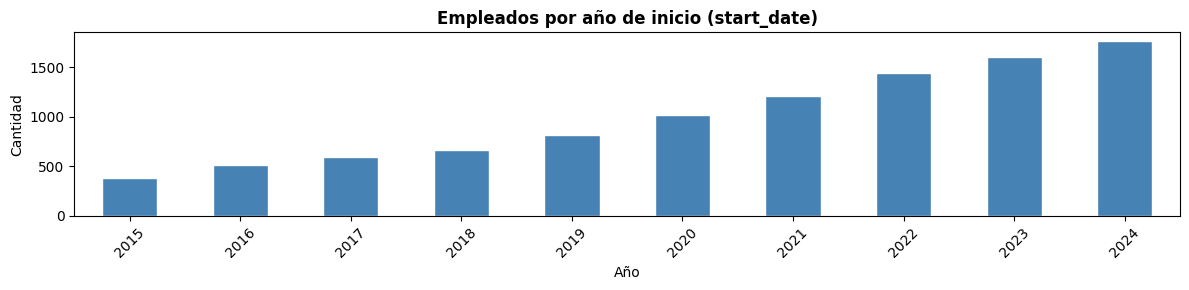

In [44]:
# Cobertura temporal
oldest = df["start_date"].min()
latest = df["start_date"].max()
span = (latest - oldest).days

print(f"Rango de fechas de inicio:")
print(f"  Más antiguo : {oldest.date()}")
print(f"  Más reciente: {latest.date()}")
print(f"  Span total  : {span} días = {span//365} años")

plt.figure(figsize=(12, 3))
df["start_year"] = df["start_date"].dt.year
year_counts = df["start_year"].value_counts().sort_index()
year_counts.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Empleados por año de inicio (start_date)", fontsize=12, fontweight="bold")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
